In [18]:
# from LadrunoGraphStyle import set_default_plot_params, main_colors
# set_default_plot_params()

In [19]:
from fem import (
    # Core
    Material,
    # Sections
    Membrane,
    # Gmsh tools
    GMSHtools,
    # Model
    FEMModel,
    # Elements
    CST, LST, Quad4, Quad9,
    # Units
    kgf, tf, kN, MPa, GPa, kg, g, cm, m, mm, N,
    # Parameters
    globalParameters,
)


import os
import numpy as np
import matplotlib.pyplot as plt
import gmsh
np.set_printoptions(suppress=True, precision=6, linewidth=400)

In [20]:
globalParameters['nDoF'] = 2
globalParameters['nDIM'] = 2

In [21]:
# General model parameters
output_path = os.getcwd()
mesh_name = 'stress_concentrations'
output_file = os.path.join(output_path, mesh_name + '.msh')

if not os.path.exists(output_path):
    os.makedirs(output_path)

In [22]:
# Initialize GMSH
gmsh.initialize()
gmsh.model.add(output_file)

# Parameters
hb = 1000
bb = 2000
hc = 200
xc = 800

N_hb = 15
N_bb = 15
N_c = 5

# Create points
gmsh.model.geo.addPoint(0, 0, 0, tag=1)
gmsh.model.geo.addPoint(xc, 0, 0, tag=2)
gmsh.model.geo.addPoint(xc + hc, hc, 0, tag=3)
gmsh.model.geo.addPoint(xc + 2 * hc, 0, 0, tag=4)
gmsh.model.geo.addPoint(bb, 0, 0, tag=5)
gmsh.model.geo.addPoint(bb, hc, 0, tag=6)
gmsh.model.geo.addPoint(bb, hb, 0, tag=7)
gmsh.model.geo.addPoint(xc + hc, hb, 0, tag=8)
gmsh.model.geo.addPoint(0, hb, 0, tag=9)
gmsh.model.geo.addPoint(0, hc, 0, tag=10)

# Create lines
gmsh.model.geo.addLine(1, 2, tag=1)
gmsh.model.geo.addLine(2, 3, tag=2)
gmsh.model.geo.addLine(3, 4, tag=3)
gmsh.model.geo.addLine(4, 5, tag=4)
gmsh.model.geo.addLine(5, 6, tag=5)
gmsh.model.geo.addLine(6, 7, tag=6)
gmsh.model.geo.addLine(7, 8, tag=7)
gmsh.model.geo.addLine(8, 9, tag=8)
gmsh.model.geo.addLine(9, 10, tag=9)
gmsh.model.geo.addLine(10, 1, tag=10)
gmsh.model.geo.addLine(10, 3, tag=11)
gmsh.model.geo.addLine(3, 6, tag=12)
gmsh.model.geo.addLine(3, 8, tag=13)

# Create curve loops and surfaces
gmsh.model.geo.addCurveLoop([8, 9, 11, 13], 1)
gmsh.model.geo.addPlaneSurface([1], 1)

gmsh.model.geo.addCurveLoop([7, -13, 12, 6], 2)
gmsh.model.geo.addPlaneSurface([2], 2)

gmsh.model.geo.addCurveLoop([10, 1, 2, -11], 3)
gmsh.model.geo.addPlaneSurface([3], 3)

gmsh.model.geo.addCurveLoop([3, 4, 5, -12], 4)
gmsh.model.geo.addPlaneSurface([4], 4)

# Set transfinite meshing
gmsh.model.geo.mesh.setTransfiniteCurve(9, N_hb)
gmsh.model.geo.mesh.setTransfiniteCurve(13, N_hb)
gmsh.model.geo.mesh.setTransfiniteCurve(6, N_hb)

gmsh.model.geo.mesh.setTransfiniteCurve(8, N_bb)
gmsh.model.geo.mesh.setTransfiniteCurve(11, N_bb)
gmsh.model.geo.mesh.setTransfiniteCurve(1, N_bb)
gmsh.model.geo.mesh.setTransfiniteCurve(7, N_bb)
gmsh.model.geo.mesh.setTransfiniteCurve(12, N_bb)
gmsh.model.geo.mesh.setTransfiniteCurve(4, N_bb)

gmsh.model.geo.mesh.setTransfiniteCurve(10, N_c)
gmsh.model.geo.mesh.setTransfiniteCurve(2, N_c)
gmsh.model.geo.mesh.setTransfiniteCurve(3, N_c)
gmsh.model.geo.mesh.setTransfiniteCurve(5, N_c)

# Set transfinite surfaces
gmsh.model.geo.mesh.setTransfiniteSurface(1, "Right", [9, 8, 3, 10])
gmsh.model.geo.mesh.setTransfiniteSurface(2, "Right", [8, 7, 6, 3])
gmsh.model.geo.mesh.setTransfiniteSurface(3, "Right", [10, 3, 2, 1])
gmsh.model.geo.mesh.setTransfiniteSurface(4, "Right", [3, 6, 5, 4])

# Synchronize before adding physical groups
gmsh.model.geo.synchronize()


def all_quads():
    # Synchronize geometry before setting meshing options
    gmsh.model.geo.synchronize()

    # Global quad mesh settings
    gmsh.option.setNumber("Mesh.RecombineAll", 1)                # Recombine all triangle meshes into quads
    gmsh.option.setNumber("Mesh.Algorithm", 8)                   # Use Delquad algorithm (for quads)
    gmsh.option.setNumber("Mesh.RecombinationAlgorithm", 2)      # Use Blossom recombination algorithm
    gmsh.option.setNumber("Mesh.Smoothing", 10)                  # Optional: improve mesh quality
    gmsh.option.setNumber("Mesh.ElementOrder", 2)

all_quads()
# gmsh.option.setNumber("Mesh.ElementOrder", 2)


# Add physical groups
# Physical curves (boundary conditions)
gmsh.model.addPhysicalGroup(1, [9, 10], tag=101, name="Pload1")
gmsh.model.addPhysicalGroup(1, [6, 5], tag=102, name="Pload2")

# Physical points (constraints)
gmsh.model.addPhysicalGroup(0, [8], tag=110, name="Con1")
gmsh.model.addPhysicalGroup(0, [3], tag=111, name="Con2")

# Physical surface (material)
gmsh.model.addPhysicalGroup(2, [1, 2, 3, 4], tag=201, name="Steel")


201

In [23]:
# Generate the mesh
gmsh.model.mesh.generate()
# Save mesh to disk
gmsh.write(output_file)
# Open GMSH GUI
gmsh.fltk.run()
# Write mesh file again (redundant)
v = gmsh.write(output_file)
# Close GMSH instance
gmsh.finalize()

In [24]:
# Define material
Steel = Material(name='Steel',
             E=200000.00, #Mpa
             nu=0.30,
             rho= 7850*kg/m**3*g * 1)

# Section
Beam = Membrane(name='Beam', thickness=20, material=Steel)

# Dictionaries
section_dictionary = {
    201: Beam,
}

Pload=1500*kN/m
load_dictionary = {
    101: {'value': Pload, 'direction': '-x'},
    102: {'value': Pload, 'direction': 'x'},
}

restrain_dictionary = {
    110: ['r', 'r'],
    111: ['r', 'r'],
}

In [25]:
# read mesh 
mesh = GMSHtools(output_file)

  MESH SUMMARY

  === NODES ===  (2117 total — showing first 3)
     Tag              x              y              z
--------------------------------------------------------------------------------
       1         0.0000         0.0000         0.0000
       2       800.0000         0.0000         0.0000
       3      1000.0000       200.0000         0.0000
--------------------------------------------------------------------------------

  === PHYSICAL GROUPS ===  (5 total)
      ID    Dim   Name
--------------------------------------------------------------------------------
     110      0   'Con1'
     111      0   'Con2'
     101      1   'Pload1'
     102      1   'Pload2'
     201      2   'Steel'
--------------------------------------------------------------------------------

  === ELEMENTS ===  (5 groups)
      ID    Dim     Type   Nodes/el   N elements   Name
--------------------------------------------------------------------------------
     110      0       15          1 

In [26]:
# Map number of nodes per element to element class
element_map = {
    3: CST,         # 3-node triangles
    4: Quad4,       # 4-node quadrilaterals
    6: LST,         # 6-node triangles
    9: Quad9,       # 9-node quadrilaterals
}

# Build FEM model — applies BCs, builds elements, assembles load vector
model = FEMModel(
    mesh                = mesh,
    section_dictionary  = section_dictionary,
    restrain_dictionary = restrain_dictionary,
    load_dictionary     = load_dictionary,
    element_class_map   = element_map,
    analysis_type       = 'planeStress',
    consistent_loads    = True,
    sampling_points     = 3,

    verbose=True,
)


  FEM MODEL SUMMARY
--------------------------------------------------------------------------------
  Analysis type    : planeStress
  Nodes            : 2117
  system_nDof      : 4234
  Elements         : 504
  Steps FEM        : 0
  Steps OpenSees   : 0

  --- Sections ---
  [201] Steel                 t=20  E=200000.00  nu=0.300

  --- Restrained nodes ---
  Node      3  [1000.  200.]                   ['r', 'r']
  Node      8  [1000. 1000.]                   ['r', 'r']

  --- Loaded nodes (dim=0) ---

  --- Load vector ---
  Non-zero DOFs in F_load : 2191
  Total applied force     : 0.0000 (x)  -3018.7332 (y)
--------------------------------------------------------------------------------



In [27]:
system_nDof = mesh.system_nDof
node_map = mesh.node_map

In [28]:
# Mesh diagnostics
model.check_mesh()


  MESH DIAGNOSTICS
--------------------------------------------------------------------------------
  Nodes            : 2117
  system_nDof      : 4234
  Elements         : 504
  Physical groups  : 5

  --- Orphan nodes ---
  OK — no orphan nodes

  --- Physical groups ---
      ID   Dim  Name                    Elements     Nodes  Section
  ------  ----  --------------------  ----------  --------  ----------
     110     0  Con1                           1         1  N/A
     111     0  Con2                           1         1  N/A
     101     1  Pload1                        18        37  N/A
     102     1  Pload2                        18        37  N/A
     201     2  Steel                        504      2117  OK

  --- Restrained nodes ---
     Tag             x             y  Condition
  ------  ------------  ------------  ------------
       3     1000.0000      200.0000  ['r', 'r']
       8     1000.0000     1000.0000  ['r', 'r']

  --- Load summary ---
  Non-zero DOFs   

In [29]:
# Solve — single step
model.solve_static(
    n_steps=1, 
    load_factor=1.0,
    verbose = True,
)


  SOLVE SUMMARY
--------------------------------------------------------------------------------
  Steps solved     : 1
  Last load factor : 1.0000
  Max |ux|         : 10.147093
  Max |uy|         : 5.463782
  Max Von Mises    : 3350.2993

  --- Equilibrium ---
  Applied  Fx: +0.0000   Reaction Rx: +0.0000   Balance: 5.4430e-07
  Applied  Fy: -3018.7332   Reaction Ry: +3017.7291   Balance: -1.0041e+00
--------------------------------------------------------------------------------



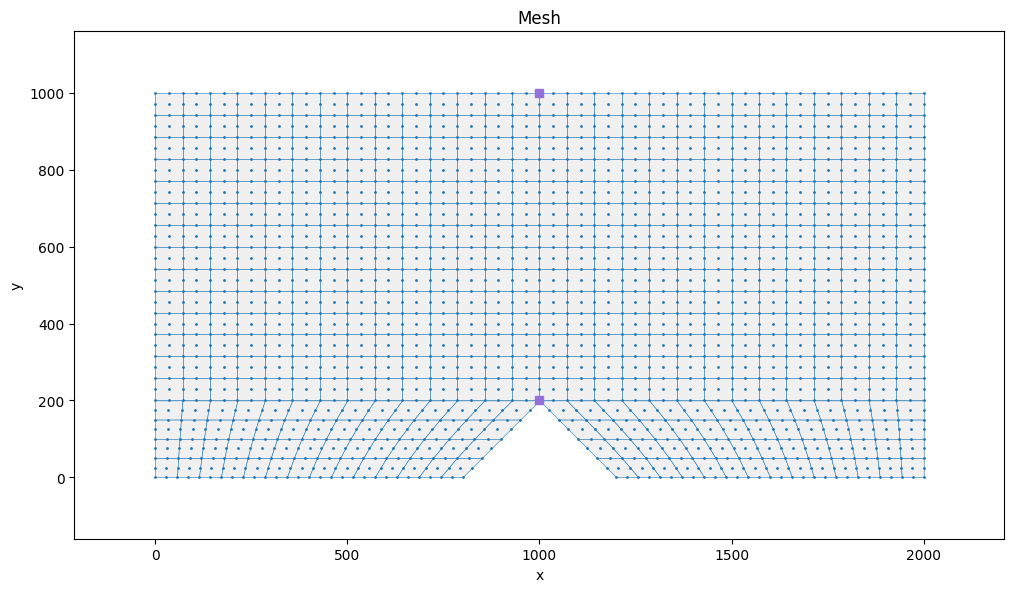

In [30]:
# Plot mesh
model.plot(
    step                = -1,
    show_node_labels    = False,
    show_element_labels = False,
    show_supports       = True,
    show_element_edges  = True,
    show_node_points    = True,
    figsize             = (12, 8),
)

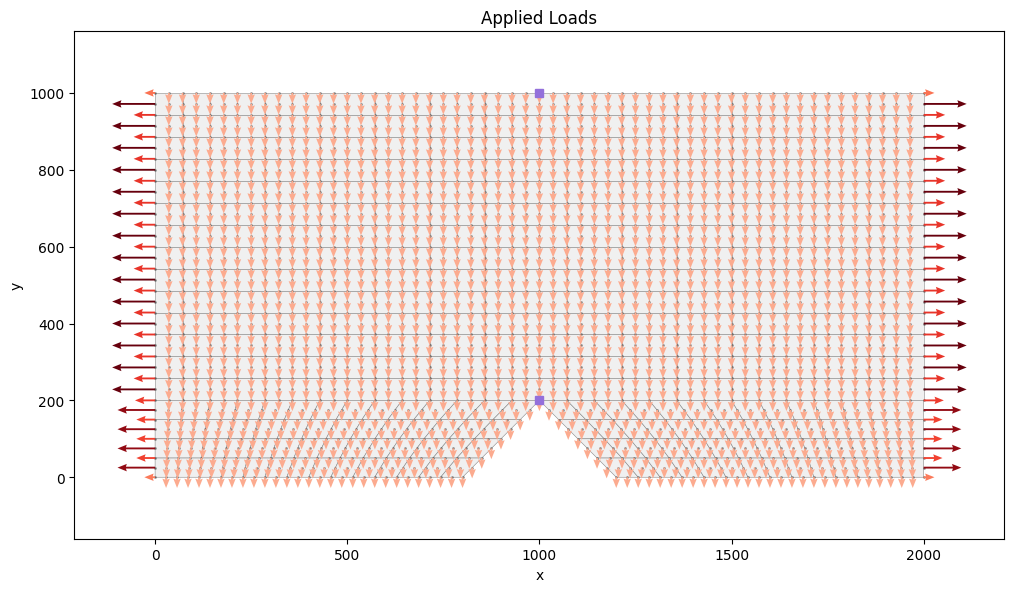

In [31]:
# Plot loads
model.plot_loads(
    show_element_edges = True,
    show_node_points   = True,
    show_supports      = True,
    figsize            = (12, 8),
)

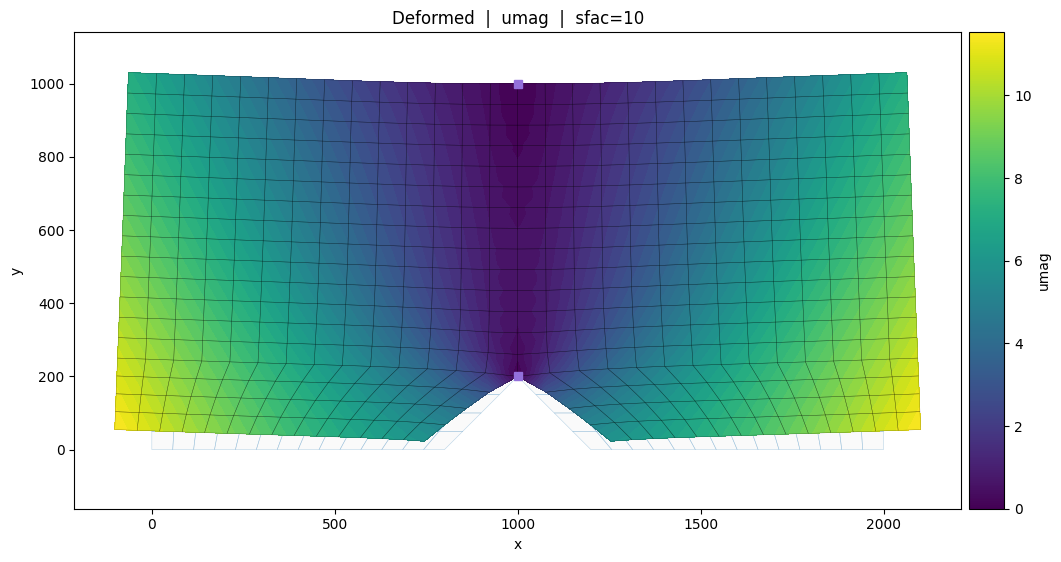

In [32]:
# Plot deformed
model.plot_deformed(
    sfac                = 10,
    step                = -1,
    component           = 'umag',   # 'ux', 'uy', 'umag'
    cmap                = 'viridis',
    show_element_edges  = True,
    show_supports       = True,
    figsize             = (12, 8),
)

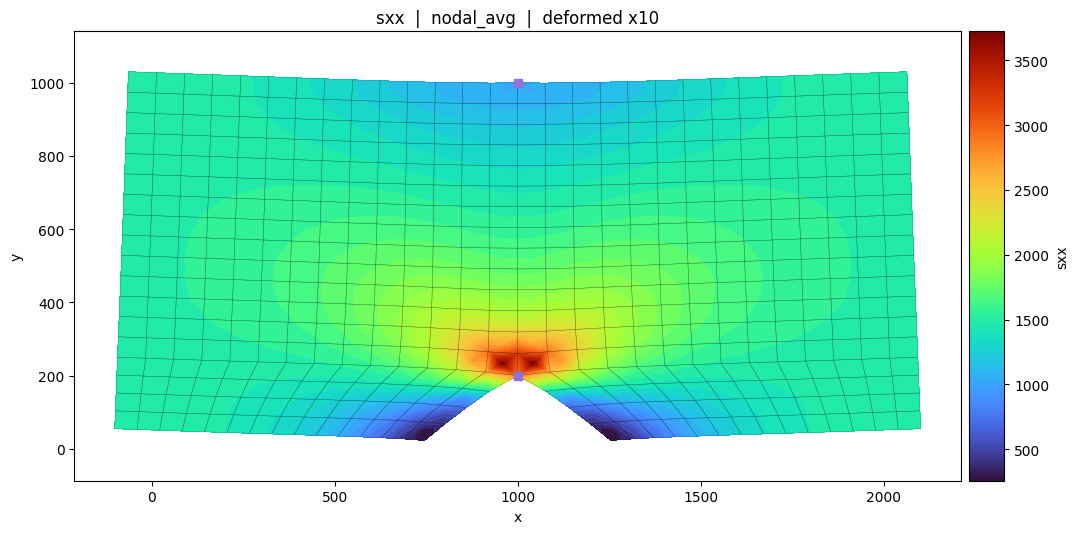

In [33]:
# Plot field
model.plot_field(
    component           = 'sxx',        # 'sxx','syy','sxy','vmis','s1','s2','exx','eyy','exy'
    source              = 'fem',
    step                = -1,
    result_type         = 'nodal_avg',  # 'nodal_avg' or 'element'
    deformed            = True,
    sfac                = 10,
    cmap                = 'turbo',
    show_element_edges  = True,
    show_supports       = True,
    figsize             = (12, 8),
)

In [36]:
# Send to gmsh — static
model.plot2gmsh(
    step            = -1,
    source         = 'fem',
    disp_factor     = 10,
    show_disp       = True,
    show_loads      = True,
    show_reactions  = True,
    show_stress     = True,
    show_strain     = True,
    show_vm         = True,
    show_averaged   = True,

)